In [185]:
#chargement des modules et extensions nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


In [186]:
# Chargement du dataset
#from google.colab import files
#uploaded = files.upload()
df = pd.read_csv("student_habits_performance.csv")



In [187]:
# Suppression de la colonne student_id
df = df.drop(columns=['student_id'], errors='ignore')

In [188]:
#Gestion des valeurs manquantes et encodage
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=df.select_dtypes(include=['object','category']).columns.tolist(), drop_first=True)
df = df.astype(float)



In [189]:
#séparation en train, test set et normalisation
X = df.drop(columns=['exam_score']).values
y = df['exam_score'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype('float32')
X_test  = scaler.transform(X_test_raw).astype('float32')
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')

print(f"Features : {X_train.shape[1]} | Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Features : 18 | Train : 800 | Test : 200


In [190]:
#construction de notre modèle global
def build_model(n_features):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(n_features,), name='couche_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(0.3, name='dropout_1'),

        layers.Dense(64, activation='relu', name='couche_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(0.2, name='dropout_2'),

        layers.Dense(32, activation='relu', name='couche_3'),
        layers.Dense(1, activation='linear', name='sortie')
    ], name='reseau_exam_score')
    return model

N_FEATURES = X_train.shape[1]
EPOCHS     = 100
BATCH_SIZE = 32

build_model(N_FEATURES).summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "reseau_exam_score"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_1 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [191]:
# entrainement de notre modèle avec un pas constant
model_1 = build_model(N_FEATURES)
model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

early_stop_1 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_1 = model_1.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop_1], verbose=1
)

y_pred_1 = model_1.predict(X_test).flatten()
mae_1 = mean_absolute_error(y_test, y_pred_1)
mse_1 = mean_squared_error(y_test, y_pred_1)
r2_1 = r2_score(y_test, y_pred_1)
print("")
print("")
print("")
print(f"[Méthode 1 – Pas constant]    MAE = {mae_1:.3f} | MSE = {mse_1:.3f} | R² = {r2_1:.3f}")

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 5316.9829 - mae: 70.8951 - val_loss: 4884.9629 - val_mae: 67.9501
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5137.1479 - mae: 69.6932 - val_loss: 4812.6001 - val_mae: 67.4419
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4941.7354 - mae: 68.3658 - val_loss: 4705.2515 - val_mae: 66.6942
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4676.3784 - mae: 66.5679 - val_loss: 4536.6030 - val_mae: 65.5253
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4325.7334 - mae: 64.0926 - val_loss: 4274.1475 - val_mae: 63.6831
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3878.2063 - mae: 60.7795 - val_loss: 3897.6646 - val_mae: 60.9223
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3327.7520 - mae: 56.2897 - val_loss: 3405.2759 - val_mae: 57.0212
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2664.9663 - mae: 50.2040 - val_loss: 2827.7549 - val_mae: 51.8898

In [192]:
# entrainement du modèle avec un pas décroissant - Version corrigée
LR0 = 5e-3

def lr_decroissant(epoch, lr):
    # Décroissance plus lente : division par racine carrée
    return LR0 / np.sqrt(1 + epoch)
    # Alternative : LR0 * (0.95 ** epoch)  # décroissance exponentielle lente

model_2 = build_model(N_FEATURES)
model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=LR0), loss='mse', metrics=['mae'])

lr_scheduler_2 = keras.callbacks.LearningRateScheduler(lr_decroissant, verbose=1)  # verbose=1 pour voir le LR
early_stop_2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_2 = model_2.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[lr_scheduler_2, early_stop_2], verbose=1
)

y_pred_2 = model_2.predict(X_test).flatten()
mae_2 = mean_absolute_error(y_test, y_pred_2)
mse_2 = mean_squared_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)
print("")
print("")
print("")
print(f"[Méthode 2 – Pas décroissant] MAE = {mae_2:.3f} | MSE = {mse_2:.3f} | R² = {r2_2:.3f}")


Epoch 1: LearningRateScheduler setting learning rate to 0.005.
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 4756.5010 - mae: 66.9282 - val_loss: 4450.0830 - val_mae: 64.8584 - learning_rate: 0.0050

Epoch 2: LearningRateScheduler setting learning rate to 0.0035355339059327372.
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3428.8755 - mae: 56.7873 - val_loss: 3403.4282 - val_mae: 57.1404 - learning_rate: 0.0035

Epoch 3: LearningRateScheduler setting learning rate to 0.002886751345948129.
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1864.8875 - mae: 40.3516 - val_loss: 1728.9371 - val_mae: 40.7940 - learning_rate: 0.0029

Epoch 4: LearningRateScheduler setting learning rate to 0.0025.
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 807.5258 - mae: 23.9488 - val_loss: 532.1749 - val_mae: 21.0572 - learning_rate: 0.0025

Epoch 5: LearningRateScheduler setting learning rate to 0.0022360679774997894.
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 348.6425 - mae: 14.8914 - val_loss: 202.3701 - val_ma

In [193]:
# entrainement du modèle avec un pas adaptatif ou hybride
# Principe : Le learning rate ne diminue que quand la performance stagne.
model_3 = build_model(N_FEATURES)
model_3.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-3), loss='mse', metrics=['mae'])

reduce_lr_3 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
)
early_stop_3 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_3 = model_3.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[reduce_lr_3, early_stop_3], verbose=1
)

y_pred_3 = model_3.predict(X_test).flatten()
mae_3 = mean_absolute_error(y_test, y_pred_3)
mse_3 = mean_squared_error(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3)
print("")
print("")
print("")
print(f"[Méthode 3 – Hybride]         MAE = {mae_3:.3f} | MSE = {mse_3:.3f} | R² = {r2_3:.3f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 5029.2627 - mae: 68.8999 - val_loss: 4640.4243 - val_mae: 66.2405 - learning_rate: 0.0050
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3741.0938 - mae: 59.3067 - val_loss: 3306.8188 - val_mae: 56.0966 - learning_rate: 0.0050
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1418.4321 - mae: 33.1259 - val_loss: 728.6987 - val_mae: 22.8457 - learning_rate: 0.0050
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 290.6302 - mae: 13.6665 - val_loss: 229.0741 - val_mae: 12.1898 - learning_rate: 0.0050
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 144.5969 - mae: 9.5489 - val_loss: 176.2162 - val_mae: 10.0301 - learning_rate: 0.0050
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 113.0676 - mae: 8.5307 - val_loss: 126.7562 - val_mae: 9.0193 - learning_rate: 0.0050
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 108.5264 - mae: 8.2419 - val_loss: 121.0678 - val_mae: 8.8313 

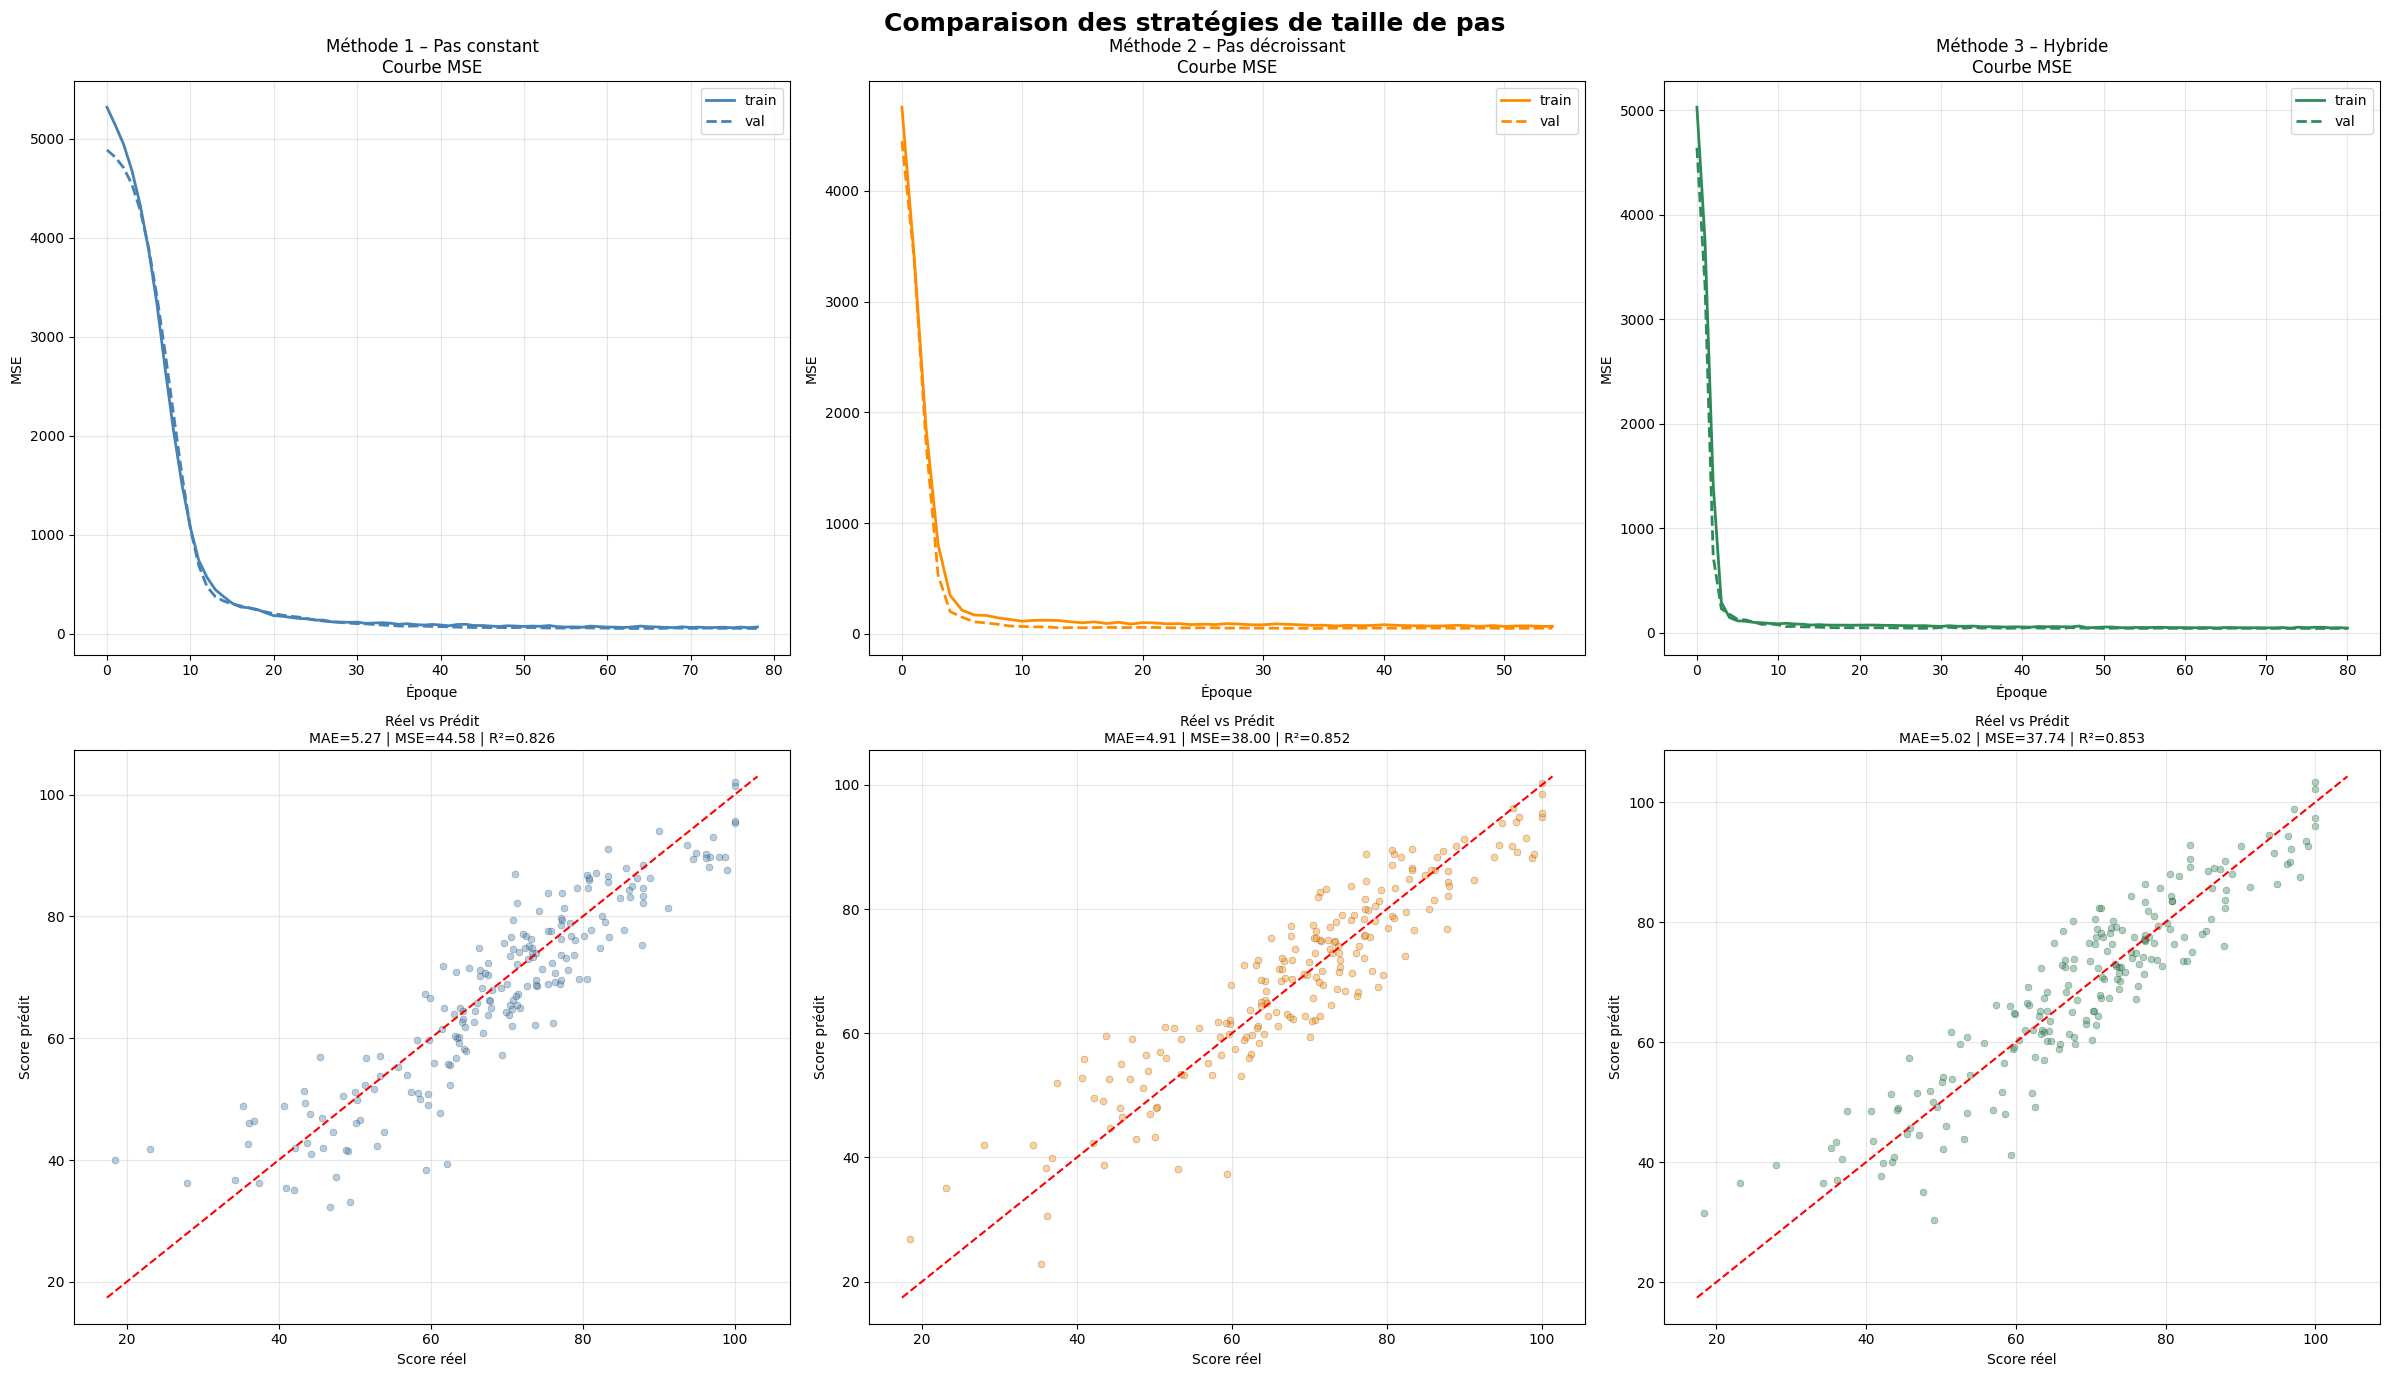

In [194]:
# comparaison visuelle des 3 méthodes d'entrainements
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle("Comparaison des stratégies de taille de pas", fontsize=18, fontweight='bold')

configs = [
    (history_1, y_pred_1, 'Méthode 1 – Pas constant',    'steelblue'),
    (history_2, y_pred_2, 'Méthode 2 – Pas décroissant', 'darkorange'),
    (history_3, y_pred_3, 'Méthode 3 – Hybride',         'seagreen'),
]

for col, (hist, y_pred, label, color) in enumerate(configs):
    axes[0, col].plot(hist.history['loss'],     color=color, label='train', linewidth=2)
    axes[0, col].plot(hist.history['val_loss'], color=color, linestyle='--', label='val', linewidth=2)
    axes[0, col].set_title(f'{label}\nCourbe MSE', fontsize=12)
    axes[0, col].set_xlabel('Époque')
    axes[0, col].set_ylabel('MSE')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].scatter(y_test, y_pred, alpha=0.4, color=color, edgecolors='k', linewidths=0.3, s=25)
    lims = [min(y_test.min(), y_pred.min())-1, max(y_test.max(), y_pred.max())+1]
    axes[1, col].plot(lims, lims, 'r--', linewidth=1.5)
    mae_v = mean_absolute_error(y_test, y_pred)
    mse_v = mean_squared_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)
    axes[1, col].set_title(f'Réel vs Prédit\nMAE={mae_v:.2f} | MSE={mse_v:.2f} | R²={r2_v:.3f}', fontsize=10)
    axes[1, col].set_xlabel('Score réel')
    axes[1, col].set_ylabel('Score prédit')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [195]:
# tableau récapitulatif
resultats = pd.DataFrame({
    'Méthode': ['1 – Pas constant', '2 – Pas décroissant', '3 – Hybride'],
    'MAE': [mae_1, mae_2, mae_3],
    'MSE': [mse_1, mse_2, mse_3],
    'R²': [r2_1, r2_2, r2_3],
    'Époques': [len(history_1.history['loss']), len(history_2.history['loss']), len(history_3.history['loss'])]
}).set_index('Méthode')

print(resultats.to_string())
print(f"\n✅ Meilleure méthode (MAE le plus bas) : {resultats['MAE'].idxmin()}")
print(f"✅ Meilleure méthode (MSE le plus bas) : {resultats['MSE'].idxmin()}")
print(f"✅ Meilleure méthode (R² le plus haut) : {resultats['R²'].idxmax()}")

                          MAE        MSE        R²  Époques
Méthode                                                    
1 – Pas constant     5.273143  44.577736  0.826160       79
2 – Pas décroissant  4.914196  38.004879  0.851792       55
3 – Hybride          5.023959  37.742958  0.852813       81

✅ Meilleure méthode (MAE le plus bas) : 2 – Pas décroissant
✅ Meilleure méthode (MSE le plus bas) : 3 – Hybride
✅ Meilleure méthode (R² le plus haut) : 3 – Hybride
